In [1]:
from pybroker import Strategy, StrategyConfig, RandomSlippageModel
from pybroker.ext.data import AKShare
import pybroker
import mplfinance as mpf
pybroker.enable_data_source_cache('akshare')

def A_share_strategy(symbols, start_date, end_date, timeframe, initial_cash, ctx_fun):
    data_source = AKShare()
    # You can also set adjust to 'qfq' or 'hfq' to adjust the data,
    # and set timeframe to '1d', '1w' to get daily, weekly data
    
    df = data_source.query(
        symbols=symbols,
        start_date=start_date,
        end_date=end_date,
        adjust="qfq",
        timeframe=timeframe,
    )    
    config = StrategyConfig(initial_cash=initial_cash, fee_mode=pybroker.common.FeeMode.ORDER_PERCENT, fee_amount=0.01, subtract_fees=True)
    slippage = RandomSlippageModel(min_pct=1.0, max_pct=5.0) # Slippage of 1-5%
    strategy = Strategy(df, start_date, end_date, config)
    strategy.set_slippage_model(slippage)
    strategy.add_execution(ctx_fun, symbols)
    return strategy, df


def plot_orders(result, df):
    df_order = result.orders
    buy = df_order[df_order['type'] == 'buy'][['date','fill_price']].rename(columns={'fill_price':'buy'})
    sell = df_order[df_order['type'] == 'sell'][['date','fill_price']].rename(columns={'fill_price':'sell'})
    orders = df.merge(buy, how='left', on = 'date').merge(sell, how='left', on = 'date')[['date','buy','sell']]



    df.set_index(['date'], inplace=True)

    chart_color = mpf.make_marketcolors(up='red', down='green', edge='inherit')
    chart_style = mpf.make_mpf_style(marketcolors=chart_color)
    # fig = mpf.figure(figsize=(90,40), style=chart_style)
    # ax1 = fig.add_axes([0.06, 0.25, 0.88, 0.60])
    # ax2 = fig.add_axes([0.06, 0.15, 0.88, 0.10], sharex=ax1)
    # ax3 = fig.add_axes([0.06, 0.05, 0.88, 0.10], sharex=ax1)
    # ax1.set_ylabel('price')
    # ax2.set_ylabel('MV')
    # ax3.set_ylabel('volume')
    add_plot = [
        mpf.make_addplot(orders['buy']*0.99, scatter = True, markersize = 20, marker = '^', color = 'r'),
        mpf.make_addplot(orders['sell']*1.01, scatter = True, markersize = 20, marker = 'v', color = 'g'),
        mpf.make_addplot(result.portfolio['market_value'], color = 'lightgrey', linestyle = '--')
    ]
    mpf.plot(df, type='line', addplot=add_plot, title='k line' , volume=True, figsize=(20,10), style=chart_style)




Loaded cached bar data.

Backtesting: 2015-01-01 00:00:00 to 2025-05-01 00:00:00

Test split: 2015-01-05 00:00:00 to 2025-04-30 00:00:00


100% (2499 of 2499) |####################| Elapsed Time: 0:00:00 Time:  0:00:000:00



Finished backtest: 0:00:08


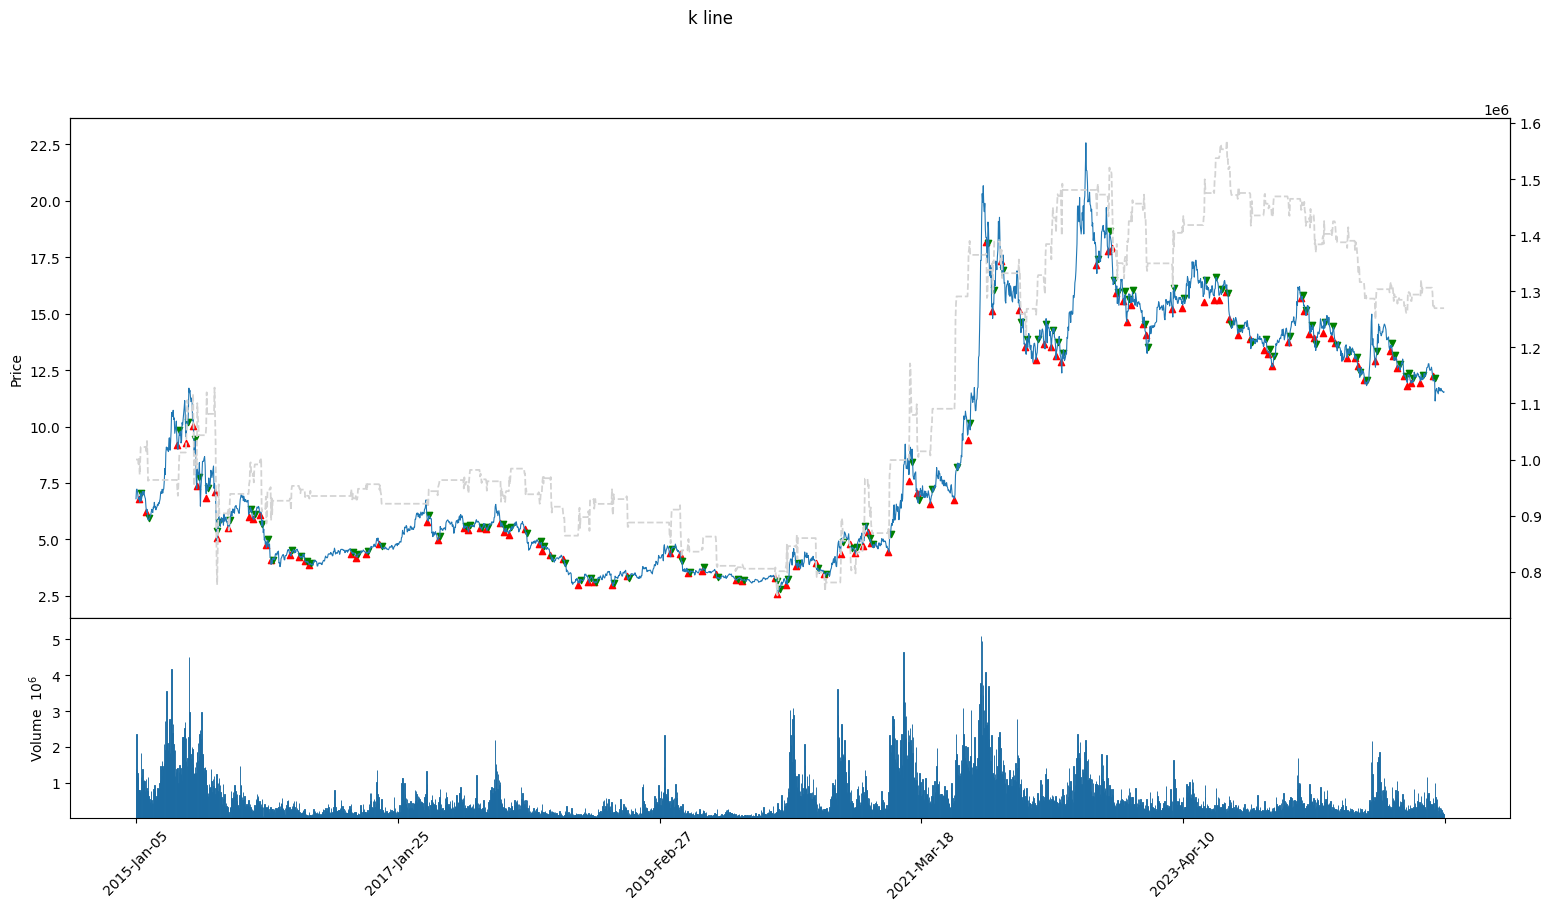

In [3]:
symbols=['600089.SH']
start_date='1/1/2015'
end_date='5/1/2025'
timeframe="1d"

initial_cash=1_000_000

strategy, df =  A_share_strategy(symbols, start_date, end_date, timeframe, initial_cash, ctx_fun=buy_low)   
result = strategy.backtest()
plot_orders(result, df)


In [2]:
def buy_low(ctx):
    # If shares were already purchased and are currently being held, then return.
    if ctx.long_pos():
        return
    # If the latest close price is less than the previous day's low price,
    # then place a buy order.
    
    if ctx.bars >= 3 and ctx.close[-1] < ctx.low[-2] and ctx.close[-1] < ctx.low[-3]:
        # Buy a number of shares that is equal to 25% the portfolio.
        ctx.buy_shares = ctx.calc_target_shares(1)
        # Set the limit price of the order.
        ctx.buy_limit_price = ctx.close[-1] - 0.01
        # Hold the position for 3 bars before liquidating (in this case, 3 days).
        ctx.hold_bars = 4



In [5]:
result.metrics_df

,name,value
0,trade_count,119
1,initial_market_value,1000000.0
2,end_market_value,1257164.71
3,total_pnl,283029.85
4,unrealized_pnl,-25865.14
5,total_return_pct,28.302985
6,total_profit,2434400.95
7,total_loss,-2151371.1
8,total_fees,25865.14
9,max_drawdown,-367504.41


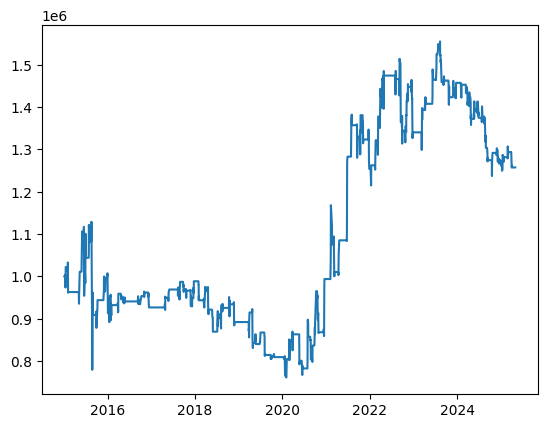

In [6]:
import matplotlib.pyplot as plt

chart = plt.subplot2grid((3, 2), (0, 0), rowspan=3, colspan=2)
chart.plot(result.portfolio.index, result.portfolio['market_value'])

In [7]:
result.portfolio

,cash,equity,margin,market_value,pnl,unrealized_pnl,fees
date,,,,,,,
2015-01-05,1000000.00,1000000.00,0.0,1000000.00,0.00,0.0,0.00
2015-01-06,1000000.00,1000000.00,0.0,1000000.00,0.00,0.0,0.00
2015-01-07,1000000.00,1000000.00,0.0,1000000.00,0.00,0.0,0.00
2015-01-08,1000000.00,1000000.00,0.0,1000000.00,0.00,0.0,0.00
2015-01-09,1000000.00,1000000.00,0.0,1000000.00,0.00,0.0,0.00
...,...,...,...,...,...,...,...
2025-04-24,1257164.71,1257164.71,0.0,1257164.71,257164.71,0.0,25865.14
2025-04-25,1257164.71,1257164.71,0.0,1257164.71,257164.71,0.0,25865.14
2025-04-28,1257164.71,1257164.71,0.0,1257164.71,257164.71,0.0,25865.14


In [8]:
df

,symbol,open,high,low,close,volume
date,,,,,,
2015-01-05,600089.SH,6.55,6.90,6.55,6.80,1387365
2015-01-06,600089.SH,6.81,7.46,6.80,7.22,2359772
2015-01-07,600089.SH,7.06,7.32,6.99,7.22,1357393
2015-01-08,600089.SH,7.34,7.46,7.05,7.09,1287869
2015-01-09,600089.SH,7.02,7.20,6.84,6.86,1170449
...,...,...,...,...,...,...
2025-04-24,600089.SH,11.62,11.66,11.55,11.57,171747
2025-04-25,600089.SH,11.58,11.60,11.54,11.58,154940
2025-04-28,600089.SH,11.58,11.63,11.54,11.54,182630
